# 1. Data Inspection
**Project:** HR Analytics: Employee Attrition  

---

## Contents
1. Setup & Load
2. Shape & Types
3. Target Distribution
4. Missing Value Audit
5. Duplicate & ID Check
6. Categorical Value Counts
7. Numeric Summary
8. Data Quality Report

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.viz_utils import set_style
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

set_style()
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

train = pd.read_csv('../data/raw/aug_train.csv')
test  = pd.read_csv('../data/raw/aug_test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)

Train shape: (19158, 14)
Test shape:  (2129, 13)


## 2. Shape & Data Types
Let's examine our data.

In [2]:
train.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


In [3]:
train.dtypes.to_frame('dtype')

,dtype
enrollee_id,int64
city,str
city_development_index,float64
gender,str
relevent_experience,str
enrolled_university,str
education_level,str
major_discipline,str
experience,str
company_size,str


**Finding:** Several columns are stored as `object` (string) that will need special handling:
- `experience` contains values `'<1'` and `'>20'` - cannot be cast directly to int
- `company_size` contains strings like `'10/49'`
- `last_new_job` contains `'never'` and `'>4'`

Will need to handle these later in the project. 

## 3. Target Distribution
Let's examine how balanced is the dataset. This determines which metrics to use for modeling.

In [4]:
print('Target value counts:')
print(train['target'].value_counts())
print()
print('Target proportions:')
print(train['target'].value_counts(normalize=True).round(4))

Target value counts:
target
0.0    14381
1.0     4777
Name: count, dtype: int64

Target proportions:
target
0.0    0.7507
1.0    0.2493
Name: proportion, dtype: float64


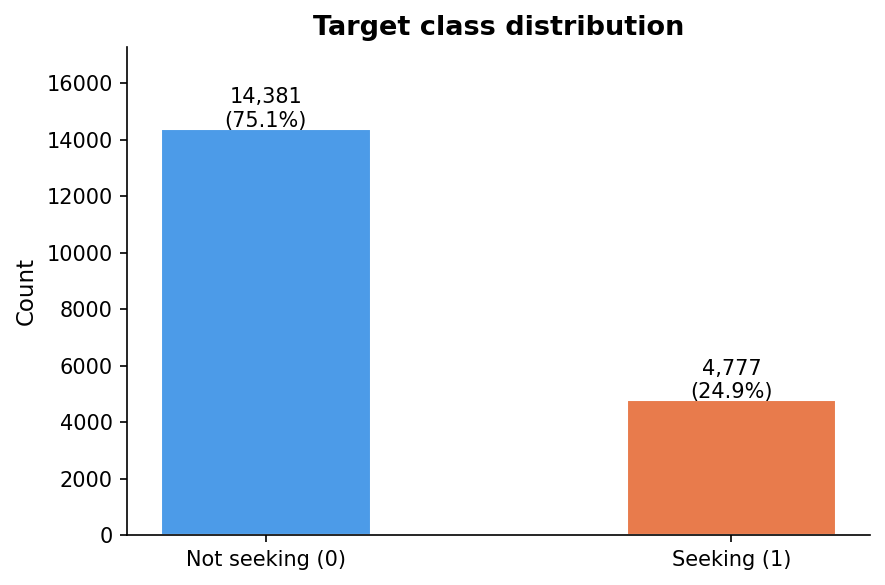

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train['target'].value_counts().sort_index()
bars = ax.bar(['Not seeking (0)', 'Seeking (1)'],
               counts.values,
               color=['#4C9BE8', '#E87B4C'],
               edgecolor='white', width=0.45)
for bar, v in zip(bars, counts.values):
    pct = v / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target class distribution')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.savefig('../outputs/figures/01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

The dataset is moderately imbalanced: 75.1% class 0 (staying) vs. 24.9% class 1 (seeking a job change). Raw accuracy is not a valid metric for this project. AUC-ROC and F1-score on the positive class will be used instead.

## 4. Missing Value Audit
Let's find out Which columns are missing data, and how much. Also, we will determine if missingness correlated with the target.

In [6]:
missing = pd.DataFrame({
    'missing_count': train.isnull().sum(),
    'missing_pct':   (train.isnull().sum() / len(train) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing[missing['missing_count'] > 0]

,missing_count,missing_pct
company_type,6140,32.05
company_size,5938,30.99
gender,4508,23.53
major_discipline,2813,14.68
education_level,460,2.40
last_new_job,423,2.21
enrolled_university,386,2.01
experience,65,0.34


In [7]:
print('Missingness vs. target rate:\n')
for col in ['company_type', 'company_size', 'gender', 'major_discipline']:
    flag   = train[col].isnull()
    r_miss = train.loc[flag,  'target'].mean()
    r_obs  = train.loc[~flag, 'target'].mean()
    diff   = r_miss - r_obs
    print(f'{col}:')
    print(f'  Target rate when missing:     {r_miss:.3f}')
    print(f'  Target rate when not missing: {r_obs:.3f}')
    print(f'  Difference:                   {diff:+.3f}\n')

Missingness vs. target rate:

company_type:
  Target rate when missing:     0.388
  Target rate when not missing: 0.184
  Difference:                   +0.204

company_size:
  Target rate when missing:     0.406
  Target rate when not missing: 0.179
  Difference:                   +0.227

gender:
  Target rate when missing:     0.308
  Target rate when not missing: 0.231
  Difference:                   +0.077

major_discipline:
  Target rate when missing:     0.195
  Target rate when not missing: 0.259
  Difference:                   -0.064



Missingness in `company_type` and `company_size` is correlated with the target - rows with missing company info have an attrition rate more than 20 percentage points higher than those without.

These missing values will be encoded as `'Unknown'` category and binary `was_missing` indicator flags will be added to preserve this signal later in the project.

## 5. Duplicate & ID Check
Let's check if there are any duplicate rows and find out if `enrollee_id` is unique.

In [8]:
print('Duplicate rows:   ', train.duplicated().sum())
print('Unique enrollee_ids:', train['enrollee_id'].nunique())
print('Total rows:         ', len(train))

Duplicate rows:    0
Unique enrollee_ids: 19158
Total rows:          19158


There are no duplicate rows in the dataset and enrollee_id is unique

## 6. Categorical Value Counts
Let's check if there are any typos, inconsistent formats, or dominant categories that need special treatment.

In [9]:
cat_cols = train.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n=== {col} ===')
    print(train[col].value_counts(dropna=False).to_string())


=== city ===
city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
city_136     586
city_67      431
city_75      305
city_102     304
city_104     301
city_73      280
city_100     275
city_71      266
city_11      247
city_61      197
city_90      197
city_28      192
city_23      182
city_65      175
city_36      160
city_173     151
city_83      143
city_50      140
city_162     128
city_46      128
city_116     128
city_138     120
city_19      119
city_64      114
city_45      113
city_74      104
city_97      104
city_57      103
city_149     102
city_159      94
city_99       94
city_128      92
city_41       89
city_10       86
city_165      82
city_105      79
city_98       79
city_123      79
city_101      75
city_40       68
city_89       67
city_150      65
city_145      63
city_24       62
city_115      54
city_142      53
city_152      51
city_76       50
city_158      49
city_13       48
city_27       47
city_91       45
city_70     

**Key findings from value counts:**
- `experience`: Contains `'<1'` and `'>20'` - requires manual ordinal mapping
- `company_size`: `'10/49'` appears to be a formatting variant of `'10-49'` - treat as equivalent
- `last_new_job`: `'never'` and `'>4'` require special handling
- `gender`: Male dominant; Female and Other are minority groups - do not impute
- `major_discipline`: STEM dominates; ~14% of values missing (NAN)


## 7. Numeric Summary
Let's look at the descriptive statistics.

In [10]:
train[['city_development_index', 'training_hours']].describe().round(3)

,city_development_index,training_hours
count,19158.000,19158.000
mean,0.829,65.367
std,0.123,60.058
min,0.448,1.000
25%,0.740,23.000
50%,0.903,47.000
75%,0.920,88.000
max,0.949,336.000


In [11]:
# Check training_hours percentiles for outlier context
percentiles = [0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
print('training_hours percentiles:')
print(train['training_hours'].quantile(percentiles).to_string())
print()
print('city_development_index range check:')
print(f'  Min: {train["city_development_index"].min()}')
print(f'  Max: {train["city_development_index"].max()}')
print(f'  All in [0,1]: {train["city_development_index"].between(0,1).all()}')

training_hours percentiles:
0.50     47.0
0.75     88.0
0.90    146.0
0.95    188.0
0.99    302.0
1.00    336.0

city_development_index range check:
  Min: 0.4479999999999999
  Max: 0.949
  All in [0,1]: True


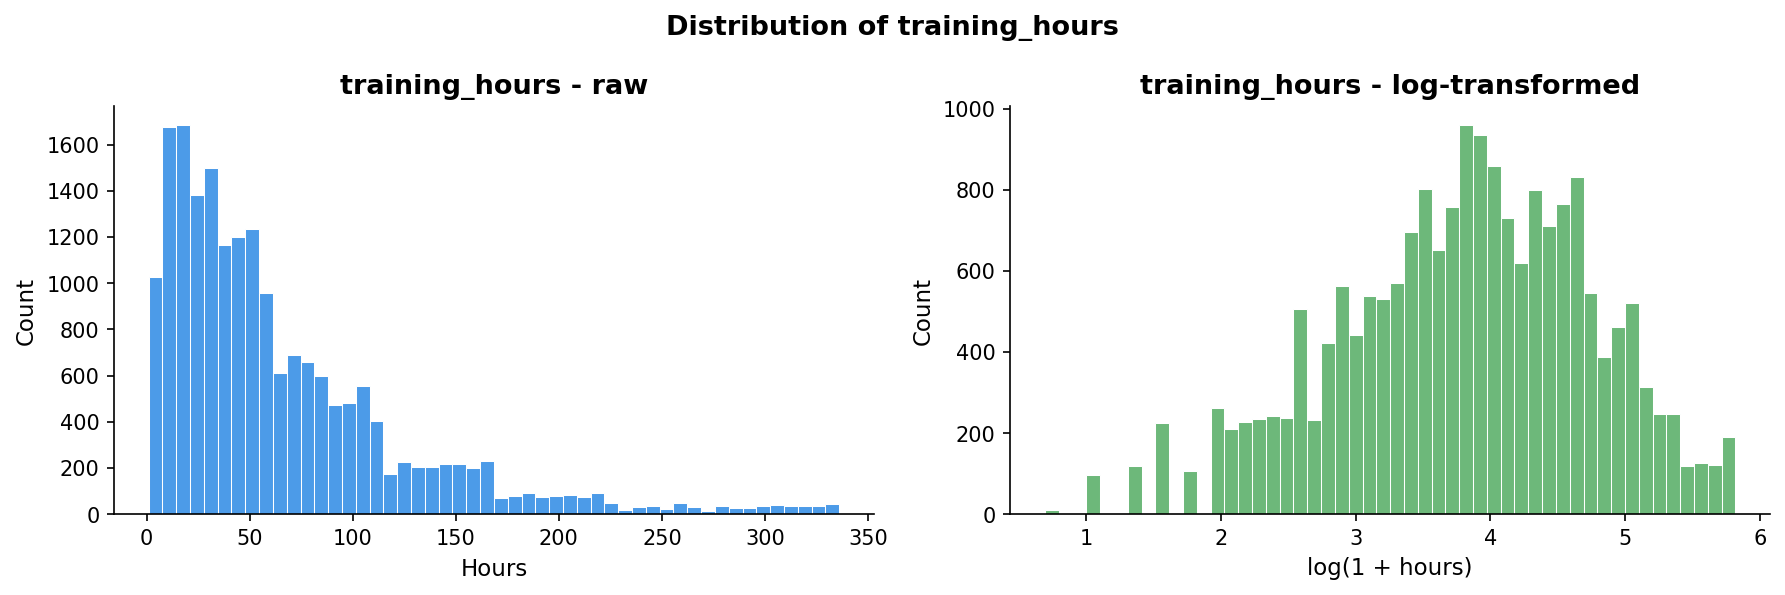

Skew (raw): 1.82
Skew (log): -0.35


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['training_hours'], bins=50,
             color='#4C9BE8', edgecolor='white', linewidth=0.5)
axes[0].set_title('training_hours - raw')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(train['training_hours']), bins=50,
             color='#6DB87A', edgecolor='white', linewidth=0.5)
axes[1].set_title('training_hours - log-transformed')
axes[1].set_xlabel('log(1 + hours)')
axes[1].set_ylabel('Count')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribution of training_hours', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_training_hours_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

print(f'Skew (raw): {train["training_hours"].skew():.2f}')
print(f'Skew (log): {np.log1p(train["training_hours"]).skew():.2f}')

Raw skew of 1.82 drops to -0.35 after the log-transform

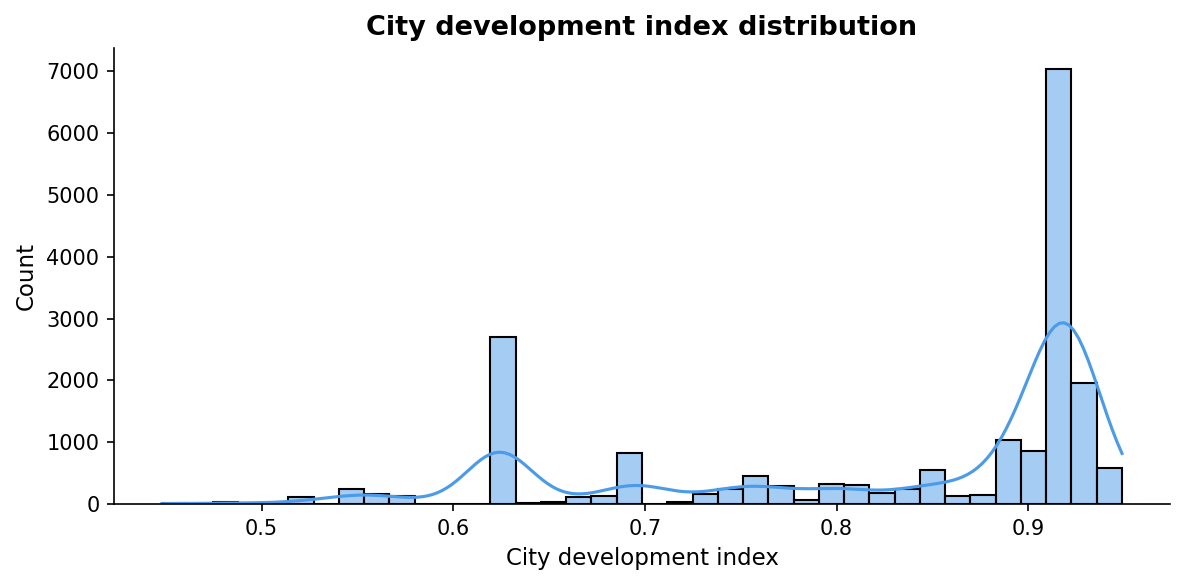

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train['city_development_index'], kde=True, ax=ax, color='#4C9BE8')
ax.set_title('City development index distribution')
ax.set_xlabel('City development index')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/03_city_development_index.png', bbox_inches='tight', dpi=150)
plt.show()

**Finding:** `training_hours` is right-skewed - 75th percentile is ~88 hours but max is ~336. We will address it later in the project. `city_development_index` is correctly bounded [0, 1] with a bimodal distribution (large cluster near 0.92, smaller cluster at lower values).

---
## 8. Data Quality Report

| Item | Finding | Phase 4 Decision |
|---|---|---|
| Shape | 19,158 rows × 14 cols (train) | - |
| Target balance | 75.1% class 0 / 24.9% class 1 | Use AUC-ROC + F1, not accuracy |
| Duplicates | 0 | - |
| ID uniqueness | ✓ unique | Drop enrollee_id before modeling |
| `company_type` | 32% missing | Encode Unknown + was_missing flag |
| `company_size` | 31% missing | Encode Unknown + was_missing flag |
| `gender` | 23% missing | Encode Unknown + was_missing flag |
| `major_discipline` | 14% missing | Encode 'No Discipline' |
| `education_level` | 2.4% missing | Median imputation |
| `experience` | 0.3% missing | Median imputation after ordinal encoding |
| `experience` dtype | object (contains '<1', '>20') | Manual ordinal map |
| `company_size` dtype | object (contains '10/49') | Manual ordinal map; '10/49' = '10-49' |
| `last_new_job` dtype | object (contains 'never', '>4') | Manual ordinal map |
| `training_hours` | Right-skewed (max=336) | log1p transform |
| `city_development_index` | Bimodal, bounded [0,1] | Keep as-is |
| `city` | 123 unique values | Drop; CDI captures the relevant signal |
